**Mini Network Lab – Correction**

<details>

<summary>Task list</summary>

# TODO Next
- [ ] Define plotly and matplotlib saving functions.
- [ ] Optimize short-circuit calculations and compare.
- [ ] Check everything with Luca.

</details>


This project requires Python 3.7 or above, to check this, we can do as follows:

In [109]:
import os
import sys
assert sys.version_info >= (3, 7)
from pathlib import Path

sys.path.append('.')
project_name =  "git/rht"
project_folder = os.path.join(os.path.expanduser('~'), project_name)
sys.path.append(project_folder)
os.chdir(project_folder)


In [110]:
# Pathways
net_file_path = "corrections/mini_network_bus.xlsx"
net_file_scope_path = Path("corrections/scope/scope20240122")
filename_3phl1 = "T0000ALL.CSV"
filename_3phl2 = "T0005ALL.CSV"
filename_3phl3 = "T0010ALL.CSV"
filename_1phl2 = "T0009ALL.CSV"

# profile_file_path = "input_data/power_profile.xlsx"
output_folder = ""
output_filename = "minireseau_results"

Before to start anything, we should add the necessary packages, as follows:

In [111]:
# Important pandapower, pandas and numpy imports
import pandapower as pp
import pandapower.shortcircuit as sc
import pandas as pd
import numpy as np
import pp_heig_plot as pp_plot
import pp_heig_simulation as pp_sim
from datetime import time
from numpy.linalg import inv
from pp_heig_plot import (plot_power_network, plot_short_circuit_result, plot_timeseries_result, plot_timestamps_powerflow_result, _time_to_str)
from pp_heig_simulation import (apply_power_profile, create_output_writer, load_power_profile_form_xlsx, load_net_from_xlsx,
                            run_time_simulation)

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mc
import plotly.express as px

# Enable grids on all plots and setting up a nice configuration
plt.rc('figure', figsize=(16, 10))
plt.rc('font', family='monospace', weight='bold', size=11)
plt.rc('axes', labelsize=11, titlesize=14)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 2

# Initial parameters and table based on the 'Mini-réseau'

_Table 1: Electrical grid parameters_

| Grid parameter                  | Real low tension values          | Simulated high tension values |
|  -----------------------------  |  ------------------------------  | ----------------------------  |
| Nominal line voltage            | $125~[\text{V}]$                 | $125~[\text{kV}]$             |
| Maximum service current         | $5~[\text{A}]$                   | $500~[\text{A}]$              |
| Maximum available power         | $1~[\text{kVA}]$                 | $100~[\text{MVA}]$            |

_Table 2: Line parameters_

- Length: $40~[\text{km}]$
- Conductor type: Cu $90~[\text{mm}]^2$
- Distance between conductors: $3.6~[\text{m}]$

| Line 1                          | Real low tension values          | Simulated high tension values |
|  -----------------------------  |  ------------------------------  | ----------------------------  |
| Resistance                      | $4 \times 0.18~[\text{Ohm}]$     | $7.12~[\text{Ohm}]$           |
| Inductive reactance             | $4 \times 0.38~[\text{Ohm}]$     | $14.6~[\text{Ohm}]$           |
| Capacitance                     | $2 \times 1.5~[\mu\text{F}]$     | $0.3~[\mu\text{F}]$           |
| Homopolar inductance            | $2 \times 0.264~[\text{Ohm}]$    | $5.28~[\text{Ohm}]$           |

- Length: $100~[\text{km}]$
- Conductor type: Al-Ac $244.3--57~[\text{mm}]^2$
- Distance between conductors: $3.6~[\text{m}]$

| Line 2                          | Real low tension values          | Simulated high tension values |
|  -----------------------------  |  ------------------------------  | ----------------------------  |
| Resistance                      | $4 \times 0.445~[\text{Ohm}]$    | $12~[\text{Ohm}]$             |
| Inductive reactance             | $4 \times 0.89~[\text{Ohm}]$     | $37.2~[\text{Ohm}]$           |
| Capacitance                     | $2 \times 4.7~[\mu\text{F}]$     | $0.94~[\mu\text{F}]$          |
| Homopolar inductance            | $2 \times 0.332~[\text{Ohm}]$    | $13.28~[\text{Ohm}]$          |

- Length: $35~[\text{km}]$
- Conductor type: Al-Ac $42.98--7.16~[\text{mm}]^2$
- Distance between conductors: $3.2~[\text{m}]$


| Line 3                          | Real low tension values          | Simulated high tension values |
|  -----------------------------  |  ------------------------------  | ----------------------------  |
| Resistance                      | $4 \times 0.715~[\text{Ohm}]$    | $26.42~[\text{Ohm}]$          |
| Inductive reactance             | $4 \times 0.40~[\text{Ohm}]$     | $37.2~[\text{Ohm}]$           |
| Capacitance                     | $2 \times 1.5~[\mu\text{F}]$     | $0.3~[\mu\text{F}]$           |
| Homopolar inductance            | $2 \times 0.264~[\text{Ohm}]$    | $5.28~[\text{Ohm}]$           |

Nominal values:

In [112]:
V_base = 125*1e3 
S_base = 100*1e6
Z_base = V_base ** 2 / S_base
f_base = 50

Define algorithm parameters:

In [113]:
tol_limit = 1e-4
iter_max = 10

Load data in **panda**power format:

In [114]:
file_path = "./corrections/mini_network_bus.xlsx"
net = load_net_from_xlsx(file_path=file_path)

First things first, we check the network in the Excel table named `mini_network_example` with the following function:

In [115]:
pp_plot.plot_power_network(net=net, plot_title="Mini network example", filename="mini_network_example")

We can now quickly look at what's inside this dictionnary of DataFrames:

In [116]:
net.ext_grid.loc[0, "vm_pu"] = 69*np.sqrt(3)/125

In [117]:
net.ext_grid

,name,bus,vm_pu,va_degree,slack_weight,s_sc_max_mva,s_sc_min_mva,rx_min,rx_max,r0x0_max,x0x_max,in_service
0,ext_grid_0,0,0.956092,0.0,1.0,100.0,None,None,0.1,None,None,True


In [118]:
net["bus"]

,name,vn_kv,type,zone,in_service
0,bus_1,125.0,b,PV-gen_1,True
1,bus_2,125.0,b,PQ-load_1,True


In [119]:
net["bus"].info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, 0 to 1
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        2 non-null      object 
 1   vn_kv       2 non-null      float64
 2   type        2 non-null      object 
 3   zone        2 non-null      object 
 4   in_service  2 non-null      bool   
dtypes: bool(1), float64(1), object(3)
memory usage: 190.0+ bytes


In [120]:
net["line"]

,name,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,max_i_ka,parallel,type,r0_ohm_per_km,x0_ohm_per_km,c0_nf_per_km,g_us_per_km,df,std_type,in_service
0,line_1,0,1,1.0,7.12,14.6,3.000000e-07,461.880215,1,None,0.2,0.3,0.0,0.0,1.0,None,True
1,line_2,0,1,1.0,12.00,37.2,9.400000e-07,461.880215,1,None,0.2,0.1,0.0,0.0,1.0,None,True


What we're doing here is navigating through the various tabs of an Excel spreadsheet...

In [121]:
net["line"].info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, 0 to 1
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           2 non-null      object 
 1   from_bus       2 non-null      int64  
 2   to_bus         2 non-null      int64  
 3   length_km      2 non-null      float64
 4   r_ohm_per_km   2 non-null      float64
 5   x_ohm_per_km   2 non-null      float64
 6   c_nf_per_km    2 non-null      float64
 7   max_i_ka       2 non-null      float64
 8   parallel       2 non-null      int64  
 9   type           0 non-null      object 
 10  r0_ohm_per_km  2 non-null      float64
 11  x0_ohm_per_km  2 non-null      float64
 12  c0_nf_per_km   2 non-null      float64
 13  g_us_per_km    2 non-null      float64
 14  df             2 non-null      float64
 15  std_type       0 non-null      object 
 16  in_service     2 non-null      bool   
dtypes: bool(1), float64(10), int64(3), object(3)
memory usage: 382.

In [122]:
net["sgen"]

,name,bus,p_mw,q_mvar,sn_mva,scaling,in_service,type,current_source


## Compare to **panda**power

Now, it is interesting to check the difference with the classical functions of **panda**power.

In [123]:
pp.runpp(net)
bus_pp_results = net.res_bus[["p_mw","q_mvar", "vm_pu", "va_degree"]]
line_pp_results = net.res_line[["p_from_mw", "q_from_mvar", "p_to_mw", "q_to_mvar", "i_from_ka", "i_to_ka"]]

print("Bus results:\n" + bus_pp_results.abs().max().to_string() + "\n")
print("Line results:\n" + line_pp_results.abs().max().to_string() + "\n\n")
print("Bus results:\n" + bus_pp_results.to_string() + "\n")
print("Line results:\n" + line_pp_results.to_string())

Bus results:
p_mw         47.981942
q_mvar       27.245850
vm_pu         0.956092
va_degree     1.580272

Line results:
p_from_mw      34.738497
q_from_mvar    17.859630
p_to_mw        33.977929
q_to_mvar      16.300038
i_from_ka       0.188698
i_to_ka         0.188698


Bus results:
        p_mw    q_mvar     vm_pu  va_degree
0 -47.981942 -27.24585  0.956092   0.000000
1  47.000000  25.00000  0.922432  -1.580272

Line results:
   p_from_mw  q_from_mvar    p_to_mw  q_to_mvar  i_from_ka   i_to_ka
0  34.738497     17.85963 -33.977929 -16.300038   0.188698  0.188698
1  13.243444      9.38622 -13.022071  -8.699962   0.078417  0.078417


In [124]:
net.line

,name,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,max_i_ka,parallel,type,r0_ohm_per_km,x0_ohm_per_km,c0_nf_per_km,g_us_per_km,df,std_type,in_service
0,line_1,0,1,1.0,7.12,14.6,3.000000e-07,461.880215,1,None,0.2,0.3,0.0,0.0,1.0,None,True
1,line_2,0,1,1.0,12.00,37.2,9.400000e-07,461.880215,1,None,0.2,0.1,0.0,0.0,1.0,None,True


In [125]:
v_load = bus_pp_results.loc[1, "vm_pu"]*V_base/(np.sqrt(3))
v_grid = bus_pp_results.loc[0, "vm_pu"]*V_base/(np.sqrt(3))
print(v_load, v_grid)

66570.78407278821 69000.0


We can visualize the result using the following functions:

In [126]:
pp_plot.plot_powerflow_result(net=net, plot_title="Mini network results", filename="mini_network_results")
net.res_bus

,vm_pu,va_degree,p_mw,q_mvar
0,0.956092,0.000000,-47.981942,-27.24585
1,0.922432,-1.580272,47.000000,25.00000


To compute the maximum value of `CH3` for each DataFrame and apply the formula, we can modify the `process_file` function to return both the processed DataFrame and the maximum value of `CH3`. Then, we can use these values to compute `Z_exp_iph`.

In [127]:
# df_sc_1ph = pd.read_csv(net_file_scope_path / filename_1ph, skiprows=range(0, 15)) # reading the dataframe
# df_sc_2ph = pd.read_csv(net_file_scope_path / filename_2ph, skiprows=range(0, 15))
# drop_cols = {
#     "CH1 Peak Detect",
#     "CH2 Peak Detect",
#     "CH3 Peak Detect",
#     "CH4 Peak Detect"
# }
# df_sc_1ph = df_sc_1ph.drop(drop_cols, axis=1)
# df_sc_2ph = df_sc_2ph.drop(drop_cols, axis=1)

def process_file(filename):
    df = pd.read_csv(net_file_scope_path / filename, skiprows=range(0, 15))
    drop_cols = {
        "CH1 Peak Detect",
        "CH2 Peak Detect",
        "CH3 Peak Detect",
        "CH4 Peak Detect"
    }
    df = df.drop(drop_cols, axis=1)
    max_ch3 = df["CH3"].max()
    return df, max_ch3

# Use the function to process the files
df_sc_3phl1, max_ch3_3phl1 = process_file(filename_3phl1)
df_sc_3phl2, max_ch3_3phl2 = process_file(filename_3phl2)
df_sc_3phl3, max_ch3_3phl3 = process_file(filename_3phl3)

df_sc_1phl2, max_ch3_1phl2 = process_file(filename_1phl2)

> [!NOTE]
> In this code, `process_file(filename)` returns both the processed DataFrame and the maximum value of `CH3`. `Z_exp_3ph_1ph` and `Z_exp_3ph_2ph` are the results of applying the formula `Ucc / I_max_3ph` to the maximum values of `CH3` for each DataFrame. Please replace `Ucc` with the actual value.

In [147]:
max_ch3_1phl2

22.4

In [128]:
df_sc_1phl2.head()

,TIME,CH1,CH2,CH3,CH4
0,-0.2040,-4.0,3,-7.152560e-08,-1.0
1,-0.2038,-2.0,9,-7.152560e-08,-0.6
2,-0.2036,-2.0,13,-7.152560e-08,-0.6
3,-0.2034,-4.0,17,8.000000e-01,-0.6
4,-0.2032,-2.0,23,8.000000e-01,-0.2


In [129]:
df_sc_3phl1.head()

,TIME,CH1,CH2,CH3,CH4
0,-0.20000,-2.0,79,3.2,2.2
1,-0.19992,-2.0,81,3.2,2.2
2,-0.19985,-2.0,81,3.2,2.2
3,-0.19977,-4.0,83,3.2,2.2
4,-0.19969,-2.0,85,3.2,2.2


In [130]:
df_sc_3phl2.head()

,TIME,CH1,CH2,CH3,CH4
0,-0.2040,-4.0,-29,-8.000000e-01,-2.2
1,-0.2038,-2.0,-23,-8.000000e-01,-2.2
2,-0.2036,-2.0,-17,-7.152560e-08,-1.8
3,-0.2034,-2.0,-13,-8.000000e-01,-1.8
4,-0.2032,-2.0,-7,-8.000000e-01,-1.4


In [131]:
df_sc_3phl3.head()

,TIME,CH1,CH2,CH3,CH4
0,-0.086000,-2.0,-71,-2.4,-3.0
1,-0.085923,-4.0,-71,-1.6,-3.0
2,-0.085846,-2.0,-69,-2.4,-3.0
3,-0.085770,-2.0,-69,-1.6,-3.0
4,-0.085693,-4.0,-67,-1.6,-3.0


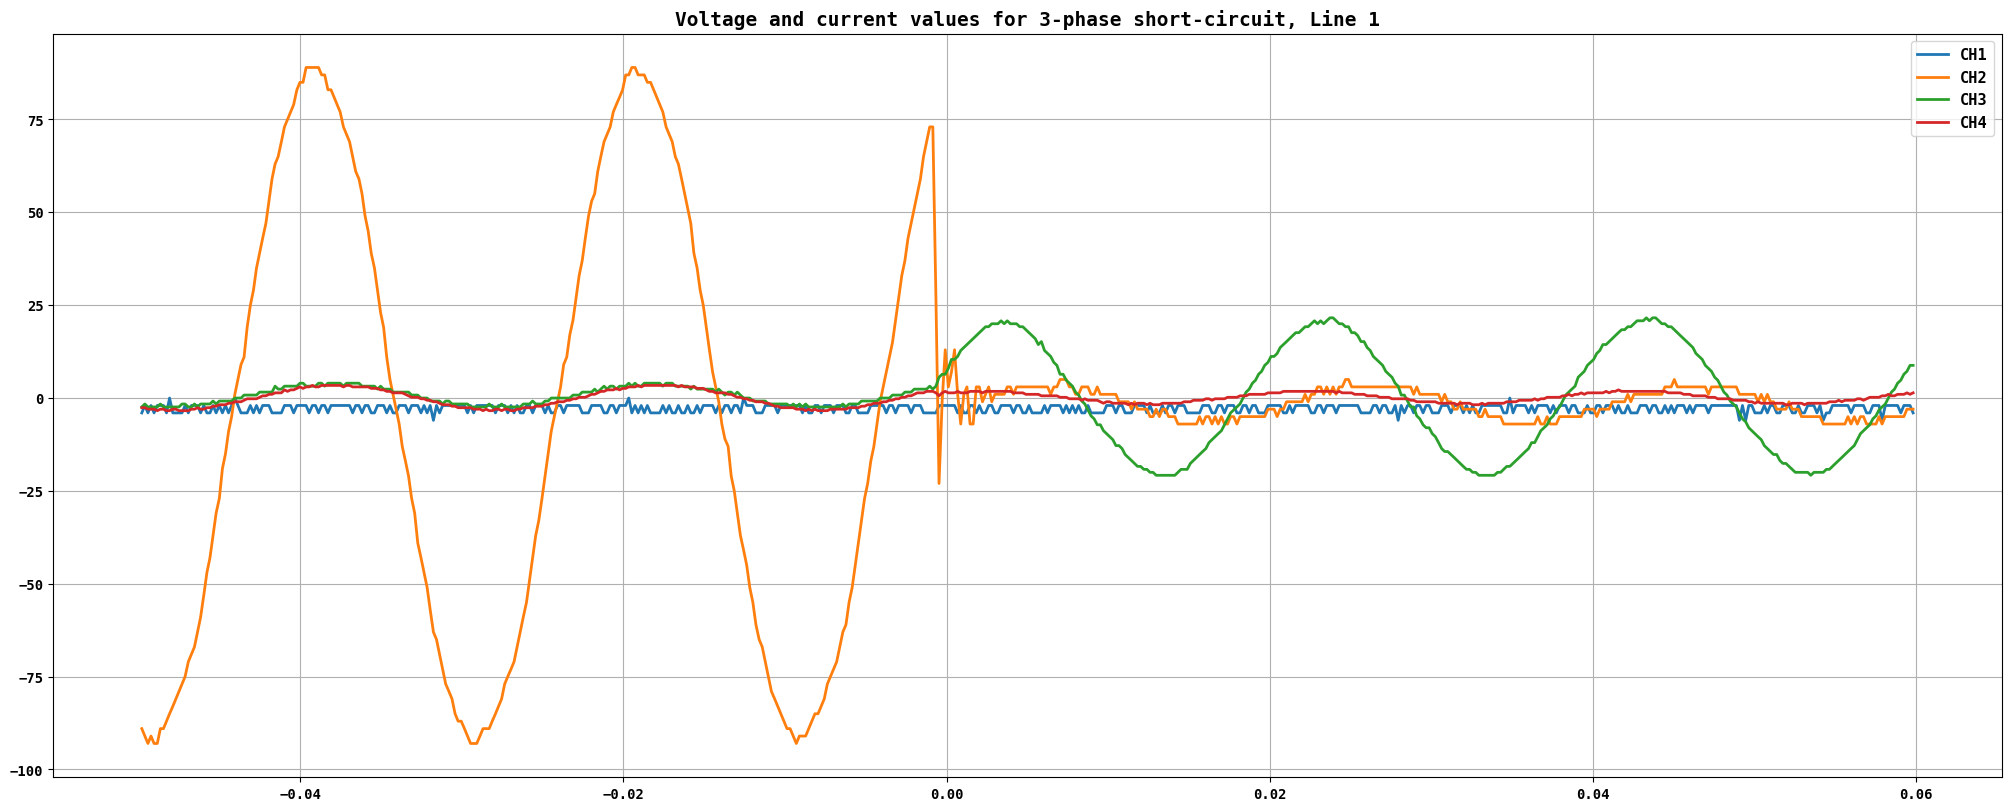

In [132]:
# Filter the DataFrame
df_sc_1phl2 = df_sc_1phl2[(df_sc_1phl2["TIME"] >= -0.05) & (df_sc_1phl2["TIME"] <= 0.06)]

fig, axs = plt.subplots(layout='constrained', sharex=True, figsize=(20, 8))

for i, column in enumerate(df_sc_3phl1.columns):
    if column == "TIME":
        continue
    axs.plot(df_sc_1phl2["TIME"], df_sc_1phl2[column], label=column)
    
plt.title("Voltage and current values for 3-phase short-circuit, Line 1", weight='bold')
plt.grid(True)
plt.legend(loc='best')

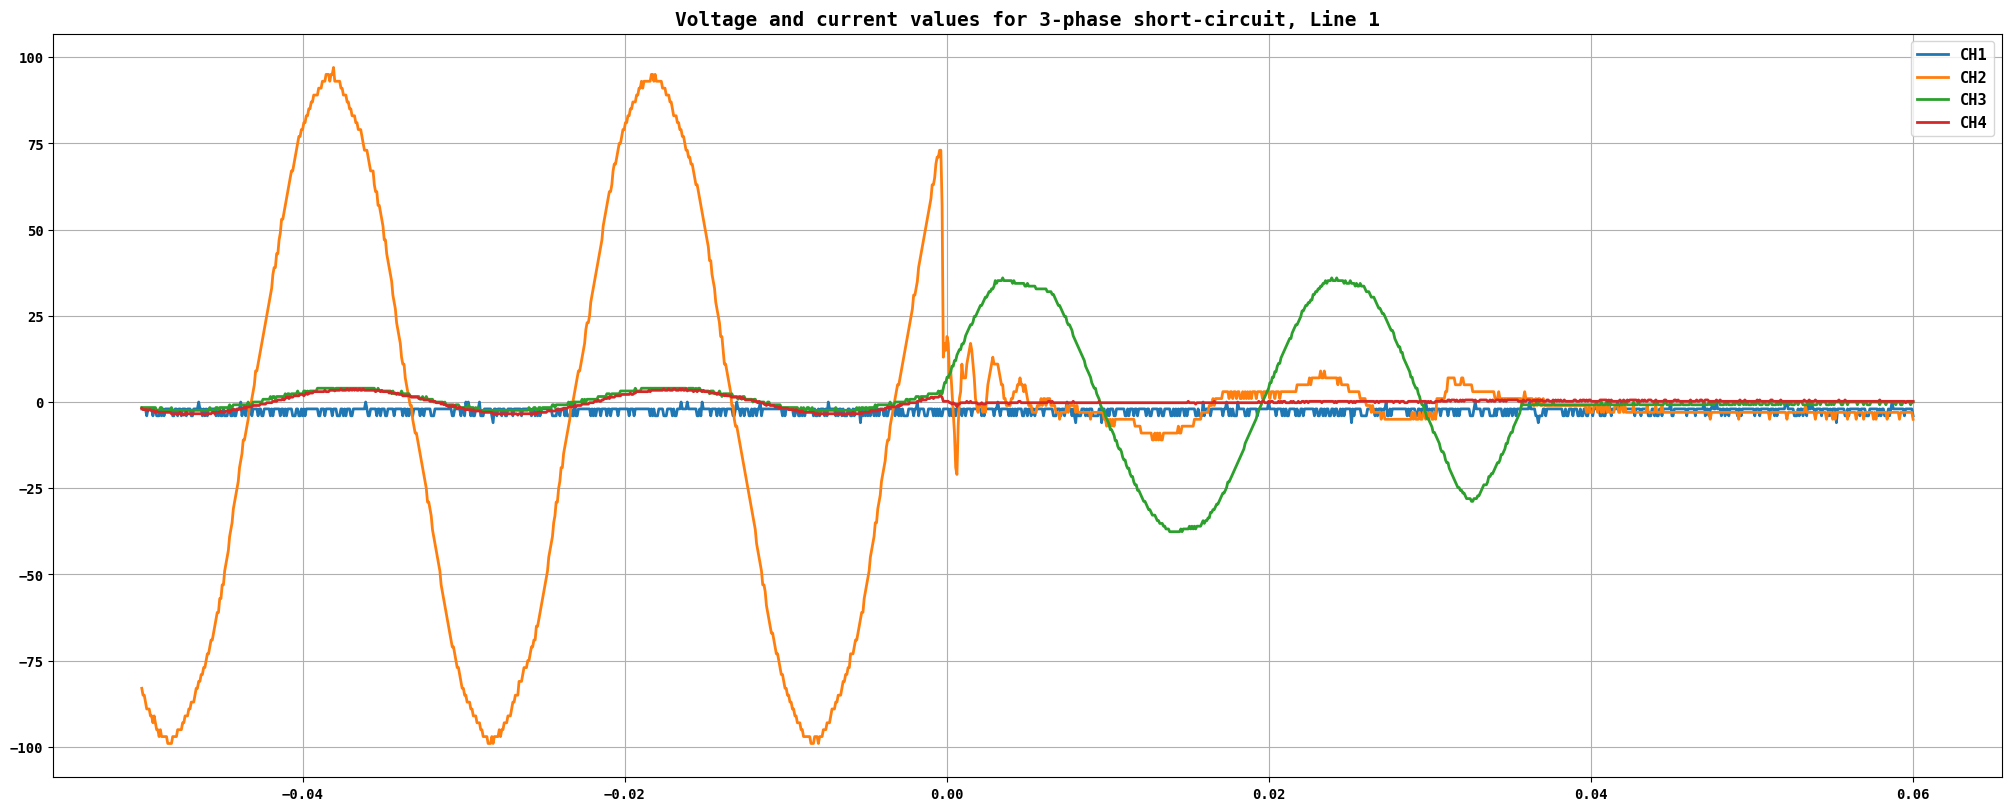

In [133]:
# Filter the DataFrame
df_sc_3phl1 = df_sc_3phl1[(df_sc_3phl1["TIME"] >= -0.05) & (df_sc_3phl1["TIME"] <= 0.06)]

fig, axs = plt.subplots(layout='constrained', sharex=True, figsize=(20, 8))

for i, column in enumerate(df_sc_3phl1.columns):
    if column == "TIME":
        continue
    axs.plot(df_sc_3phl1["TIME"], df_sc_3phl1[column], label=column)
    
plt.title("Voltage and current values for 3-phase short-circuit, Line 1", weight='bold')
plt.grid(True)
plt.legend(loc='best')

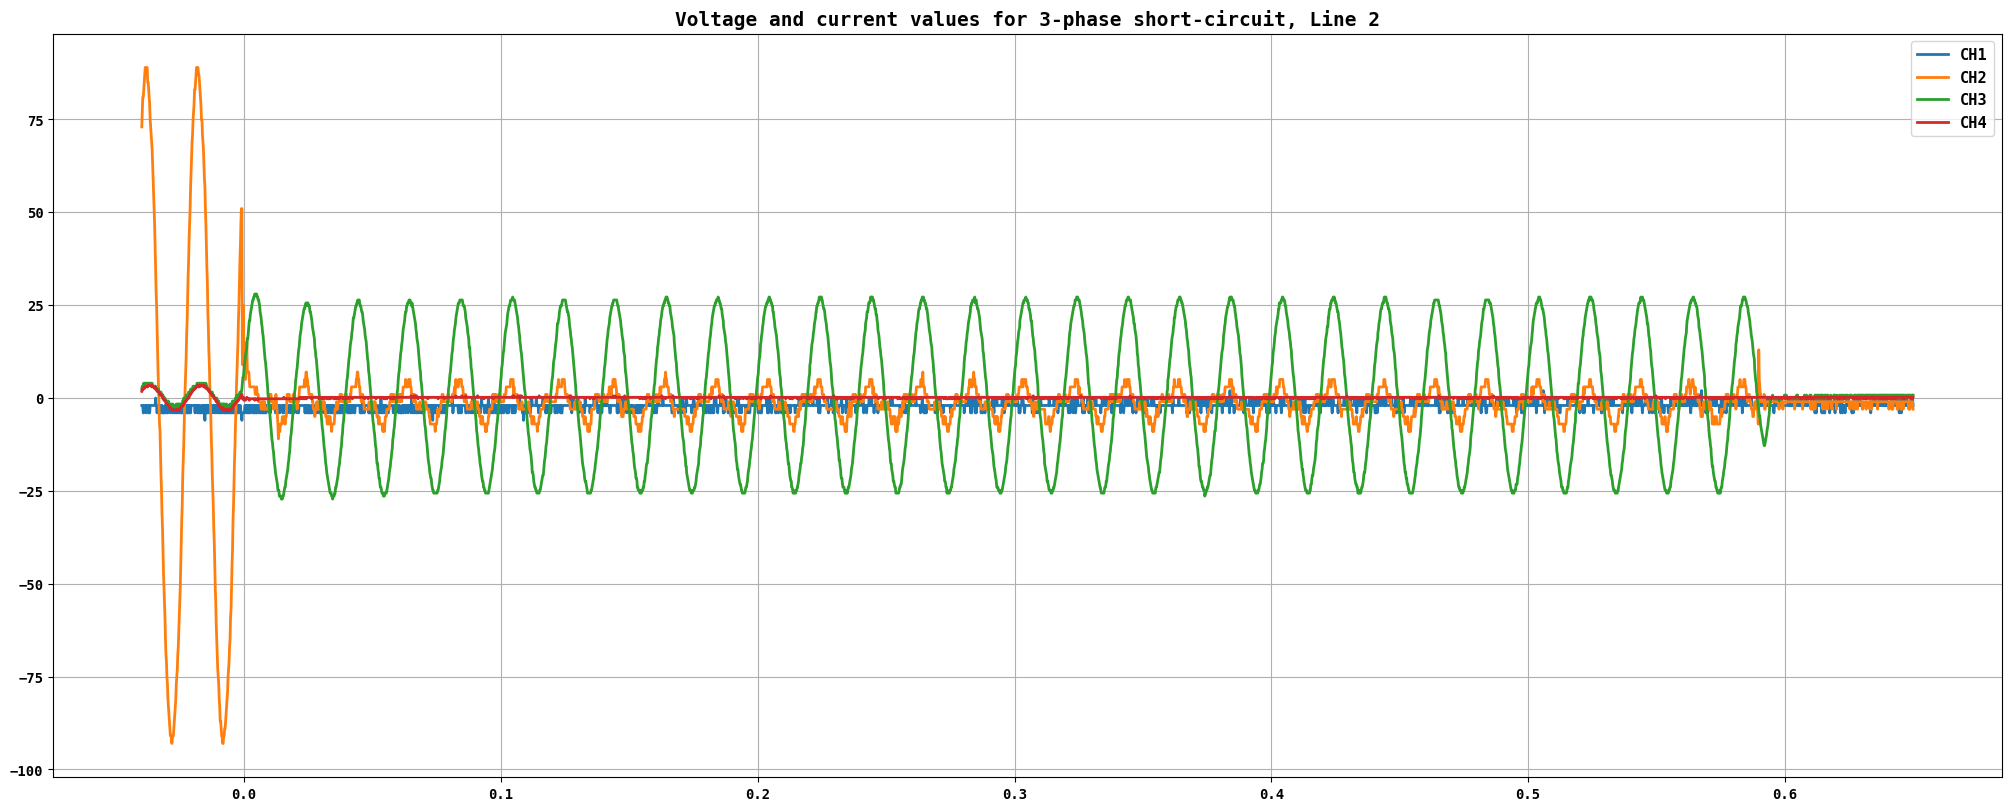

In [134]:
# Filter the DataFrame
df_sc_3phl2 = df_sc_3phl2[(df_sc_3phl2["TIME"] >= -0.04) & (df_sc_3phl2["TIME"] <= 0.65)]

fig, axs = plt.subplots(layout='constrained', sharex=True, figsize=(20, 8))

for i, column in enumerate(df_sc_3phl2.columns):
    if column == "TIME":
        continue
    axs.plot(df_sc_3phl2["TIME"], df_sc_3phl2[column], label=column)
    
plt.title("Voltage and current values for 3-phase short-circuit, Line 2", weight='bold')
plt.grid(True)
plt.legend(loc='best')

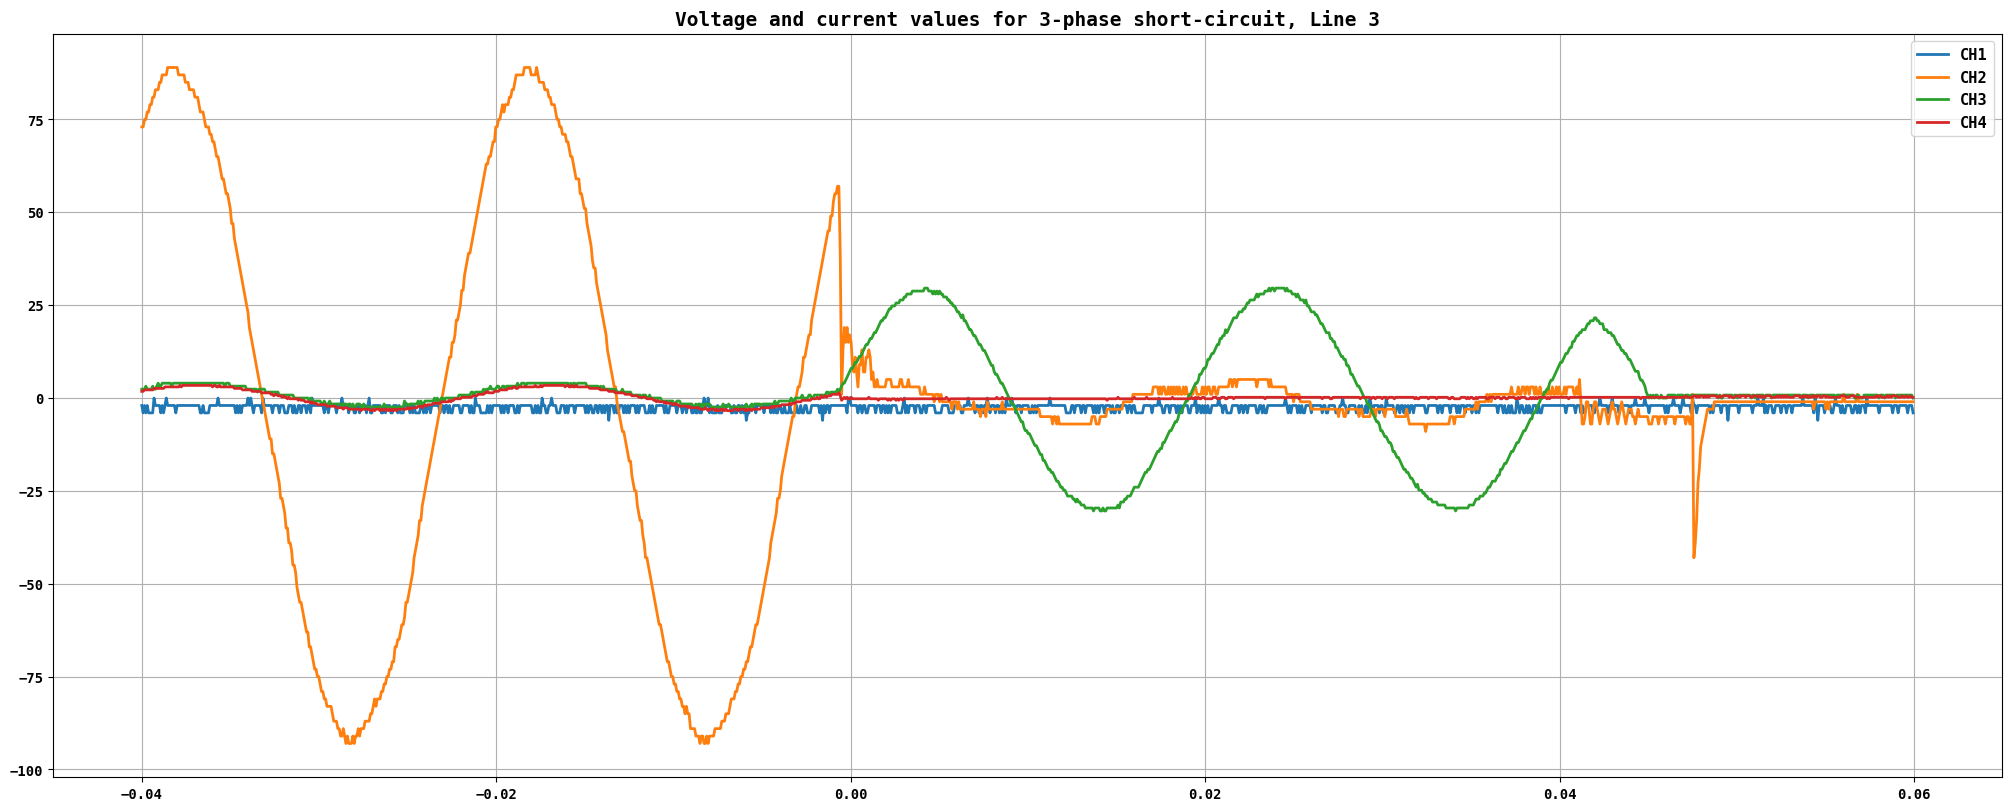

In [135]:
# Filter the DataFrame
df_sc_3phl3 = df_sc_3phl3[(df_sc_3phl3["TIME"] >= -0.04) & (df_sc_3phl3["TIME"] <= 0.06)]

fig, axs = plt.subplots(layout='constrained', sharex=True, figsize=(20, 8))

for i, column in enumerate(df_sc_3phl3.columns):
    if column == "TIME":
        continue
    axs.plot(df_sc_3phl3["TIME"], df_sc_3phl3[column], label=column)
    
plt.title("Voltage and current values for 3-phase short-circuit, Line 3", weight='bold')
plt.grid(True)
plt.legend(loc='best')

<details>

<summary>Potential improvements for this graph</summary>

- [ ] We now, need to create a plot that starts at "TIME" = 0.000 and stops when either "CH2" or "CH4" equals 0. 
- [ ] Please replace "CH2" and "CH4" with the correct column names if they are different in your DataFrame. 
- [ ] To stop the graph when "CH2" is decreasing to zero for at least 2 ms, you need to find the first instance where "CH2" is close to zero and stays close to zero for at least 2 ms.
- [ ] We need plotly for better graph.

</details>

### Short-circuit impedance computation

In [136]:
# c = 1.1 # for high voltage calculation
# z_sc3phl1 = c*net.ext_grid.loc[0, "vm_pu"]/(max_ch3_3phl1/np.sqrt(3))
# print(z_sc3phl1, max_ch3_3phl1)

# c = 1.1 # for high voltage calculation
# z_sc3phl2 = c*net.ext_grid.loc[0, "vm_pu"]/(max_ch3_3phl2/np.sqrt(3))
# print(z_sc3phl2, max_ch3_3phl2)

# c = 1.1 # for high voltage calculation
# z_sc3phl3 = c*net.ext_grid.loc[0, "vm_pu"]/(max_ch3_3phl3/np.sqrt(3))
# print(z_sc3phl3, max_ch3_3phl3)

Some automation:

In [137]:
def calculate_and_print(c, max_ch3, label):
    ik_sc3ph = max_ch3*100/np.sqrt(2)
    z_sc3ph = c * 69*np.sqrt(3)*1e3 / (ik_sc3ph / np.sqrt(3)) 
    print(f"For {label}, z_sc3ph is {z_sc3ph:.2f} Ohm and max_ch3 is {ik_sc3ph:.2f} A")
    return z_sc3ph

c = 1.1  # for high voltage calculation

z_sc3phl1 = calculate_and_print(c, max_ch3_3phl1, "L1")
z_sc3phl2 = calculate_and_print(c, max_ch3_3phl2, "L2")
z_sc3phl3 = calculate_and_print(c, max_ch3_3phl3, "L3")

For L1, z_sc3ph is 89.45 Ohm and max_ch3 is 2545.58 A
For L2, z_sc3ph is 115.01 Ohm and max_ch3 is 1979.90 A
For L3, z_sc3ph is 108.79 Ohm and max_ch3 is 2093.04 A


In [138]:
def calculate_z_eq(R1, X1, line, z_sc3ph):
    z_eq = z_sc3ph - np.sqrt(R1**2 + X1**2)/2
    print(f"For {line}, z_eq is {z_eq:.2f}")
    return z_eq

# Calculate r1 and r0 for each line
R1 = [7.12, 12, 26.42]  # positive sequence resistance for lines 1, 2, 3
R0 = [0, 0, 0]  # zero sequence resistance for lines 1, 2, 3

# Calculate x1 and x0 for each line
X1 = [14.6, 37.2, 14.4]  # positive sequence reactance for lines 1, 2, 3
X0 = [5.28, 13.28, 5.28]  # zero sequence reactance for lines 1, 2, 3

max_ch3 = [max_ch3_3phl1, max_ch3_3phl2, max_ch3_3phl3]
def calculate_and_print_2(c, max_ch3, R1, X1,line):
    ik_sc3ph = max_ch3*100/np.sqrt(2)
    z_sc3ph = c * 69*np.sqrt(3)*1e3 / (ik_sc3ph / np.sqrt(3)) 
    z_eq = z_sc3ph - np.sqrt(R1**2 + X1**2)/2
    print(f"For {line}, z_sc3ph is {z_sc3ph:.2f} Ohm and max_ch3 is {ik_sc3ph:.2f} A")
    print(f"For {line}, z_eq is {z_eq:.2f}")
# Calculate and print z_eq for each line
for i in range(3):
    calculate_and_print_2(c, max_ch3[i], R1[i], X1[i], f"Line {i+1}")


For Line 1, z_sc3ph is 89.45 Ohm and max_ch3 is 2545.58 A
For Line 1, z_eq is 81.33
For Line 2, z_sc3ph is 115.01 Ohm and max_ch3 is 1979.90 A
For Line 2, z_eq is 95.46
For Line 3, z_sc3ph is 108.79 Ohm and max_ch3 is 2093.04 A
For Line 3, z_eq is 93.74


How to find the line impedance of the grid for these short-circuits?

In [139]:
z_cc_trafo = np.sqrt(3)*9e-2*110e3**2/100e6
z_cc_trafo

18.86203329442507

In [140]:
125e3**2

15625000000.0

> [!TIP]
> In this code, `calculate_and_print(c, max_ch3, label)` is a function that calculates `z_sc3ph` and prints it along with `max_ch3` in a formatted string. The `{:.2f}` in the string formats the numbers to have 2 decimal places. The function is then used to calculate and print the values for "L1", "L2", and "L3".

## Short-circuit theory for this lab

To get the correct values for for the line impedances, we have to compute the following parameters:

$$
\begin{align*}
    R_\text{per km} &= \dfrac{R_\text{line i}}{\text{length i}}~[\text{Ohm}]\\[1em]
    X_\text{per km} &= \dfrac{X_\text{line i}}{\text{length i}}~[\text{Ohm}]\\[1em]
    C_\text{per km} &= \dfrac{C_\text{line i}}{\text{length i}}~[\text{F}]
\end{align*}
$$

> [!TIP]
> To calculate the short-circuit current, we often use the per-unit system.

_Max short-circuit current in case of one transformer_:

$$
\begin{align*}
	I_\text{sc} &= \dfrac{I_\text{n} \times 100}{U_\text{sc}}\\[1em]
	I_\text{n} &= \dfrac{S \times 10^3}{\sqrt{3}\,U_{\text{grid},0}}
\end{align*}
$$

and:

- $S$: kVA rating of the transformer
- $U_{\text{grid},0}$: phase-to-phase secondary no-load voltage
- $I_\text{n}$: rated current of the transformer
- $I_\text{sc}$: short-circuit current in amps
- $U_\text{sc}$: short-circuit impedance voltage of the transformer in %.

_Short-circuits are always following this relationship_:

$$
\begin{align*}
	I_\text{sc} = \dfrac{U_\text{sc}}{Z_{i,\text{sc}}}
\end{align*}
$$

with:

- $Z_{i,\text{sc}}$: the short-circuit impedance component.
- $i \in \{\mathbb{N}; 1,\ldots , 3\}$.

**Please refer to RHT RE08 course's mathematical relationships**.


<details>

<summary>Useful references for short-circuits</summary>

### References



```bibtex

@manual{Bozorg2023,
	title		= "{\'E}tude des courants de court-circuit",
	author		= "Bozorg", "Mokhtar",
	organization	= "Haute Ecole d'Ing{\'e}nierie et de Gestion du Canton de Vaud (HEIG-VD)",
	?_address	= "",
	?_edition	= "",
	year		= "2023",
	?_month		= "",
	?_note		= "",
}

@manual{SchneiderElec2022InstallGuide,
	title		= "",
	author		= "Schneider Electric",
	?_organization	= "",
	?_address	= "",
	?_edition	= "",
	year		= "2024",
	?_month		= "",
	note		= "https://www.electrical-installation.org/enwiki/3-phase_short-circuit_current_(Isc)_at_any_point_within_a_LV_installation",
}

</details>

In [141]:
??sc.calc_sc

Signature:
sc.calc_sc(
    net,
    bus=None,
    fault='3ph',
    case='max',
    lv_tol_percent=10,
    topology='auto',
    ip=False,
    ith=False,
    tk_s=1.0,
    kappa_method='C',
    r_fault_ohm=0.0,
    x_fault_ohm=0.0,
    branch_results=False,
    check_connectivity=True,
    return_all_currents=False,
    inverse_y=True,
    use_pre_fault_voltage=False,
)
Source:   
def calc_sc(net, bus=None,
            fault="3ph", case='max', lv_tol_percent=10, topology="auto", ip=False,
            ith=False, tk_s=1., kappa_method="C", r_fault_ohm=0., x_fault_ohm=0.,
            branch_results=False, check_connectivity=True, return_all_currents=False,
            inverse_y=True, use_pre_fault_voltage=False):

    """
    Calculates minimal or maximal symmetrical short-circuit currents.
    The calculation is based on the method of the equivalent voltage source
    according to DIN/IEC EN 60909.
    The initial short-circuit alternating current *ikss* is the basis of the short-circuit
 

In [142]:
net.line

,name,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,max_i_ka,parallel,type,r0_ohm_per_km,x0_ohm_per_km,c0_nf_per_km,g_us_per_km,df,std_type,in_service
0,line_1,0,1,1.0,7.12,14.6,3.000000e-07,461.880215,1,None,0.2,0.3,0.0,0.0,1.0,None,True
1,line_2,0,1,1.0,12.00,37.2,9.400000e-07,461.880215,1,None,0.2,0.1,0.0,0.0,1.0,None,True


> [!IMPORTANT]
> It may be useful to overcome the following warnings and pitfalls.

The error message `KeyError: 'x0x_min'` is indicating that the `x0x_min` key is not found in the DataFrame. From the DataFrame you've shown, it seems like `x0x_min` is indeed present. However, the values for `x0x_min` are 0.361644 and 0.356989, which are not zero. 

The issue might be related to the `sc.calc_sc(net, fault="1ph", case="min")` function call. This function might be expecting `x0x_min` to be defined in a different part of the `net` object, or it might be a bug in the function itself.

Here are a few things you can try:

1. Check if `x0x_min` is defined in the correct place. According to the pandapower documentation, `x0x_min` should be defined in `net.ext_grid`, not `net.line`. If `x0x_min` is not defined in `net.ext_grid`, you should define it there.

2. If `x0x_min` is defined correctly, the issue might be a bug in the `sc.calc_sc(net, fault="1ph", case="min")` function. In this case, you should report the issue to the pandapower developers.

3. As a workaround, you can try calculating the short circuit without specifying `case="min"`. If this works, it means the issue is related to the handling of `x0x_min` in the `sc.calc_sc(net, fault="1ph", case="min")` function.

The `KeyError: 'x0x_min'` error suggests that the `x0x_min` key is not found in the network data structure. In the context of pandapower, `x0x_min` is the minimum zero sequence reactance to positive sequence reactance ratio. 

If you need to use `x0x_min` value, you should add it to your network parameters. However, pandapower does not directly support `x0x_min` as a parameter for lines. You can calculate it from the zero sequence and positive sequence reactances.

The positive sequence reactance `x1` can be calculated from the line impedance `X` and the zero sequence reactance `x0` from the zero-sequence inductance. The ratio `x0x_min` is then `x0/x1`.

Here is how you can add `x0x_min` to our power grid parameters:

In [143]:
net.ext_grid

,name,bus,vm_pu,va_degree,slack_weight,s_sc_max_mva,s_sc_min_mva,rx_min,rx_max,r0x0_max,x0x_max,in_service
0,ext_grid_0,0,0.956092,0.0,1.0,100.0,None,None,0.1,None,None,True


In [144]:
net.line

,name,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,max_i_ka,parallel,type,r0_ohm_per_km,x0_ohm_per_km,c0_nf_per_km,g_us_per_km,df,std_type,in_service
0,line_1,0,1,1.0,7.12,14.6,3.000000e-07,461.880215,1,None,0.2,0.3,0.0,0.0,1.0,None,True
1,line_2,0,1,1.0,12.00,37.2,9.400000e-07,461.880215,1,None,0.2,0.1,0.0,0.0,1.0,None,True


In [145]:
# Calculate r1 and r0 for each line
R1_LINE1 = 7.12  # positive sequence resistance for line 1
R0_LINE1 = 0  # zero sequence resistance for line 1

R1_LINE2 = 12  # positive sequence resistance for line 2
R0_LINE2 = 0  # zero sequence resistance for line 2

# Calculate x1 and x0 for each line
X1_LINE1 = 14.6  # positive sequence reactance for line 1
X0_LINE1 = 5.28  # zero sequence reactance for line 1

X1_LINE2 = 37.2  # positive sequence reactance for line 2
X0_LINE2 = 13.28  # zero sequence reactance for line 2

# Calculate r0x0_max for each line
r0x0_max_line1 = R0_LINE1 / X0_LINE1
r0x0_max_line2 = R0_LINE2 / X0_LINE2

# Calculate x0x_min for each line
x0x_min_line1 = X0_LINE1 / X1_LINE1
x0x_min_line2 = X0_LINE2 / X1_LINE2

# Add x0x_min to the line parameters
# net.ext_grid['x0x_min'] = pd.Series([x0x_min_line1, x0x_min_line2], index=net.ext_grid.index)
# net.ext_grid['r0x0_min'] = pd.Series([r0x0_max_line1, r0x0_max_line2], index=net.ext_grid.index)
net.ext_grid['x0x_min'] = x0x_min_line1
net.ext_grid['r0x0_min'] = r0x0_max_line1
net.ext_grid["s_sc_min_mva"] = S_base
net.ext_grid["rx_min"] = 0.1
net.line["endtemp_degree"] = 25

# sc.calc_sc(net, fault="3ph", case="min")

for fault in ["3ph", "2ph", "1ph"]:
    sc.calc_sc(net, fault=fault, case="min", ip=True)
    plot_short_circuit_result(
        net=net, filename=fault + "_sc_results", plot_title=fault +" short-circuit results"
    )
net.res_bus_sc

,ikss_ka,rk0_ohm,xk0_ohm,ip_ka,rk_ohm,xk_ohm
0,587550.378587,3.155444e-24,0.000056,NaN,0.000016,0.000155
1,9.331305,1.144975e-01,0.087804,NaN,4.698004,10.537806


In [146]:
%whos

Variable                           Type             Data/Info
-------------------------------------------------------------
Path                               type             <class 'pathlib.Path'>
R0                                 list             n=3
R0_LINE1                           int              0
R0_LINE2                           int              0
R0_LINE3                           int              0
R1                                 list             n=3
R1_LINE1                           float            7.12
R1_LINE2                           int              12
R1_LINE3                           float            26.42
S_base                             float            100000000.0
V_base                             float            125000.0
X0                                 list             n=3
X0_LINE1                           float            5.28
X0_LINE2                           float            13.28
X0_LINE3                           float            5.28
X1  